# Restaurant_Rating_Prediction

### All required Labraries

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
from dash import Dash, dcc, html
import plotly.express as px

#### Load Data

In [2]:
data = pd.read_csv("Data/Dataset .csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Preprocessing The Data

In [3]:
min_rating = data['Aggregate rating'].min()
max_rating = data['Aggregate rating'].max()
print(f"Minimum Rating: {min_rating}")
print(f"Maximum Rating: {max_rating}")

Minimum Rating: 0.0
Maximum Rating: 4.9


In [4]:
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [5]:
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [6]:
city_count = data['City'].value_counts()
print(f"There are {city_count} Cities")

There are City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64 Cities


In [7]:
zero_rating = (data['Aggregate rating'] == 0).sum()
print(f"There are {zero_rating} '0 rating'")

There are 2148 '0 rating'


In [8]:
data = data.drop(["Restaurant ID", "Restaurant Name", "Address","Locality", "Locality Verbose", "Switch to order menu", "Rating color", "Rating text", "Currency", "Country Code"], axis=1, errors='ignore')
data

,City,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,Makati City,121.027535,14.565443,"French, Japanese, Desserts",1100,Yes,No,No,3,4.8,314
1,Makati City,121.014101,14.553708,Japanese,1200,Yes,No,No,3,4.5,591
2,Mandaluyong City,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Yes,No,No,4,4.4,270
3,Mandaluyong City,121.056475,14.585318,"Japanese, Sushi",1500,No,No,No,4,4.9,365
4,Mandaluyong City,121.057508,14.584450,"Japanese, Korean",1500,Yes,No,No,4,4.8,229
...,...,...,...,...,...,...,...,...,...,...,...
9546,��stanbul,28.977392,41.022793,Turkish,80,No,No,No,3,4.1,788
9547,��stanbul,29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,No,No,No,3,4.2,1034
9548,��stanbul,29.034640,41.055817,"Italian, World Cuisine",170,No,No,No,4,3.7,661
9549,��stanbul,29.036019,41.057979,Restaurant Cafe,120,No,No,No,4,4.0,901


In [9]:
data.dropna(subset =["Cuisines"], inplace= True)
data.isna().sum()
data.shape

(9542, 11)

In [10]:
data = data[data["Aggregate rating"] != 0]
data = data.copy()
data.shape

(7394, 11)

In [11]:
binary_cols = ["Has Table booking", "Has Online delivery", "Is delivering now"]
binary_mapping = {'Yes': 1,
           'No' : 0
          }
for col in binary_cols:
    data.loc[:, col] = data[col].map(binary_mapping)

print(data[['Has Table booking', 'Has Online delivery', 'Is delivering now']].head())

  Has Table booking Has Online delivery Is delivering now
0                 1                   0                 0
1                 1                   0                 0
2                 1                   0                 0
3                 0                   0                 0
4                 1                   0                 0


In [12]:
data['Cuisines'] = data['Cuisines'].apply(
    lambda x: [i.strip() for i in str(x).split(",")] if isinstance(x, str) else x
)
data_exploded = data.explode("Cuisines")
data['Cuisines']

0             [French, Japanese, Desserts]
1                               [Japanese]
2       [Seafood, Asian, Filipino, Indian]
3                        [Japanese, Sushi]
4                       [Japanese, Korean]
                       ...                
9546                             [Turkish]
9547     [World Cuisine, Patisserie, Cafe]
9548              [Italian, World Cuisine]
9549                     [Restaurant Cafe]
9550                                [Cafe]
Name: Cuisines, Length: 7394, dtype: object

In [13]:
freq_count = data_exploded['Cuisines'].value_counts()
#top10 cuisines
print("These are the top 10 cuisines: ")
top10 = freq_count.head(10).index
top10

These are the top 10 cuisines: 


Index(['North Indian', 'Chinese', 'Fast Food', 'Mughlai', 'Italian',
       'Continental', 'Cafe', 'Desserts', 'Bakery', 'South Indian'],
      dtype='object', name='Cuisines')

In [14]:
for i in top10:
    data[i] = data['Cuisines'].apply(lambda x: 1 if i in x else 0)
top10_set = set(top10)
data['Other_Cuisines'] = data['Cuisines'].apply(
    lambda x: 1 if isinstance(x, list) and not any(cuisine in top10_set for cuisine in x) else 0
)
data['Cuisine_Count'] = data['Cuisines'].apply(lambda x: len(x) if isinstance(x, list) else 0)
data = data.drop('Cuisines', axis=1)

In [15]:
city_count = data['City'].value_counts()
top10city = city_count.head(10).index
print("Top 10 Cities:")
top10city

Top 10 Cities:


Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Ahmedabad', 'Lucknow', 'Guwahati', 'Amritsar'],
      dtype='object', name='City')

## Features Scaling

In [16]:
for i in top10city:
    data[i] = data['City'].apply(lambda x: 1 if i == x else 0)
data['Other_city'] = data['City'].apply(lambda x: 1 if x not in top10city else 0)
data = data.drop('City', axis=1)

In [17]:
data['Votes'] = np.log1p(data['Votes'])
# Interaction between popularity and price tier
data['Price_Popularity'] = data['Price range'] * data['Votes']

In [33]:
data['Cost_per_person'] = data['Average Cost for two']/2

In [35]:
data['Is_Expensive'] = (data['Average Cost for two'] > data['Average Cost for two'].median()).astype(int)

In [37]:
data['popularity'] = data['Votes'] * data['Price range']

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7394 entries, 0 to 9550
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Longitude             7394 non-null   float64
 1   Latitude              7394 non-null   float64
 2   Average Cost for two  7394 non-null   int64  
 3   Has Table booking     7394 non-null   object 
 4   Has Online delivery   7394 non-null   object 
 5   Is delivering now     7394 non-null   object 
 6   Price range           7394 non-null   int64  
 7   Aggregate rating      7394 non-null   float64
 8   Votes                 7394 non-null   float64
 9   North Indian          7394 non-null   int64  
 10  Chinese               7394 non-null   int64  
 11  Fast Food             7394 non-null   int64  
 12  Mughlai               7394 non-null   int64  
 13  Italian               7394 non-null   int64  
 14  Continental           7394 non-null   int64  
 15  Cafe                  7394

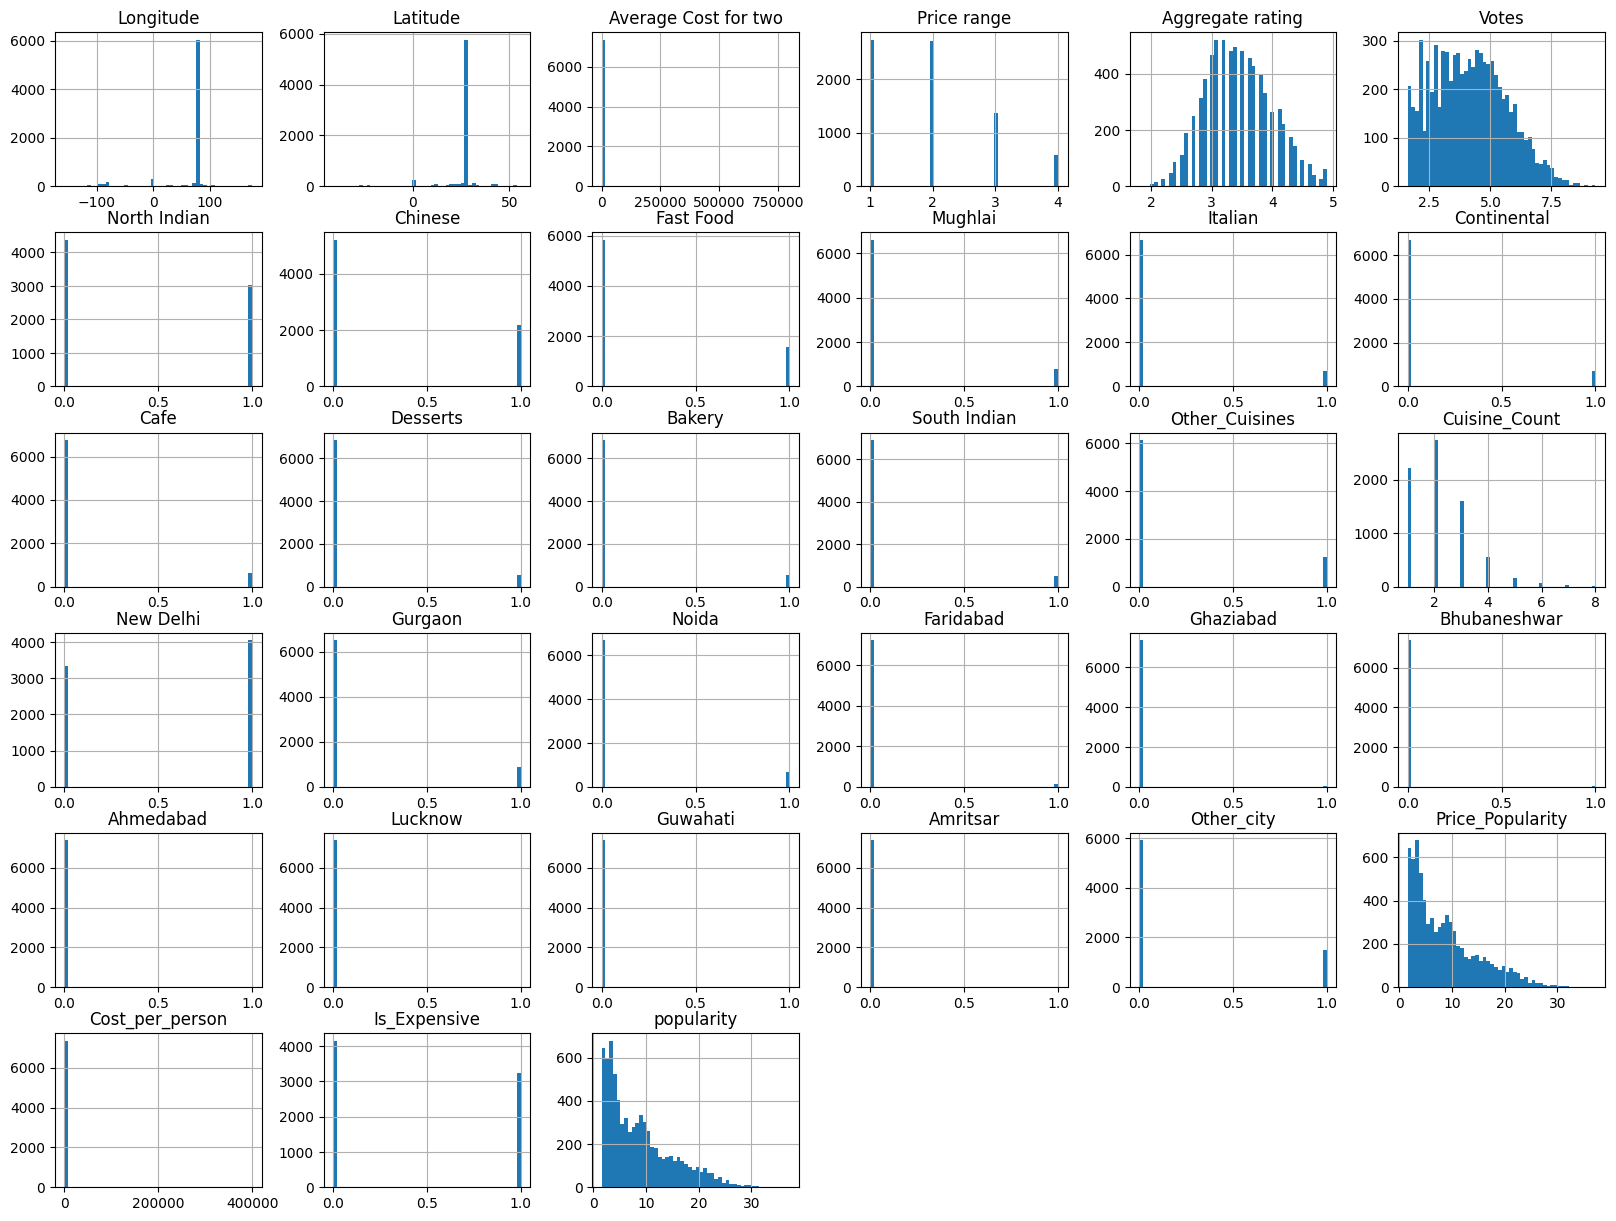

In [39]:
data.hist(bins=50, figsize=(20,15))
plt.show()

### **Train-Test Splitting**

In [40]:
target = 'Aggregate rating'
X = data.drop(target, axis=1)
y= data[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)

(5915, 35)


In [41]:
scale = StandardScaler()
num_cols = ['Longitude', 'Latitude', 'Votes', 'Average Cost for two', 'Price range']
X_train.loc[:,num_cols] = scale.fit_transform(X_train[num_cols])
X_test.loc[:,num_cols] = scale.transform(X_test[num_cols])

C:\Users\Admin\AppData\Local\Temp\ipykernel_12080\3463380485.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.04568659 -0.06408116 -0.07327845 ... -0.03648931 -0.01502898
 -0.07327845]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:,num_cols] = scale.fit_transform(X_train[num_cols])
C:\Users\Admin\AppData\Local\Temp\ipykernel_12080\3463380485.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.03484769 -1.04433614 -1.04433614 ...  0.03484769  1.11403153
  2.19321536]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:,num_cols] = scale.fit_transform(X_train[num_cols])
C:\Users\Admin\AppData\Local\Temp\ipykernel_12080\3463380485.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future e

## Train a Model

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# X_test[['Longitude', 'Latitude','Votes','Average Cost for two', 'Price range']] = scale.transform(X_test[['Longitude', 'Latitude','Votes','Average Cost for two', 'Price range']])
predict_val = lr.predict(X_test)
predict_val

array([3.01028437, 2.91947059, 2.95072136, ..., 3.36369794, 3.32876229,
       3.79620466], shape=(1479,))

In [43]:
ds = DecisionTreeRegressor(random_state=42)
ds.fit(X_train, y_train)
pred_ds = ds.predict(X_test)
pred_ds

array([3.1, 2.9, 2.9, ..., 3.5, 3.3, 4.1], shape=(1479,))

In [44]:
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,  # Ensures each leaf has enough data to be statistically valid
    max_features='sqrt',
    max_depth=15,
    min_samples_split=5, # Helps decorrelate trees for better generalization
    random_state=42,
    n_jobs=-1            # Uses all your CPU cores to run faster
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
pred_rf

array([3.00941457, 2.99154535, 3.01985183, ..., 3.42798573, 3.29882171,
       3.91994949], shape=(1479,))

## Evaluate The Model

In [45]:
def evaluate(y_test, predict_val, model_name):
    mse = mean_squared_error(y_test, predict_val)
    r2 = r2_score(y_test, predict_val)
    print(f"Model: {model_name}")
    print("MSE: ", mse)
    print("R2 Score: ", r2)
    print("-"*30)

evaluate(y_test, predict_val,"Linear Regression")
evaluate(y_test, pred_ds,"DecisionTreeRegressor")
evaluate(y_test, pred_rf,"RandomForestRegressor")

Model: Linear Regression
MSE:  0.1371889272048596
R2 Score:  0.5569144308501304
------------------------------
Model: DecisionTreeRegressor
MSE:  0.23799188640973631
R2 Score:  0.23134634411534505
------------------------------
Model: RandomForestRegressor
MSE:  0.12424491070402743
R2 Score:  0.5987203333760113
------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_12080\3188357333.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(range(len(indices)), feature_importance[indices])


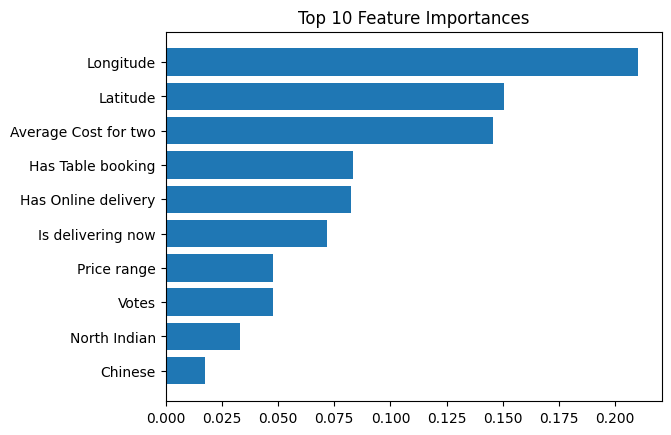

In [60]:
feature_importance = pd.Series(rf.feature_importances_,
                               index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)
indices = np.argsort(feature_importance)[-10:]
plt.figure()
plt.title("Top 10 Feature Importances")
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.show()

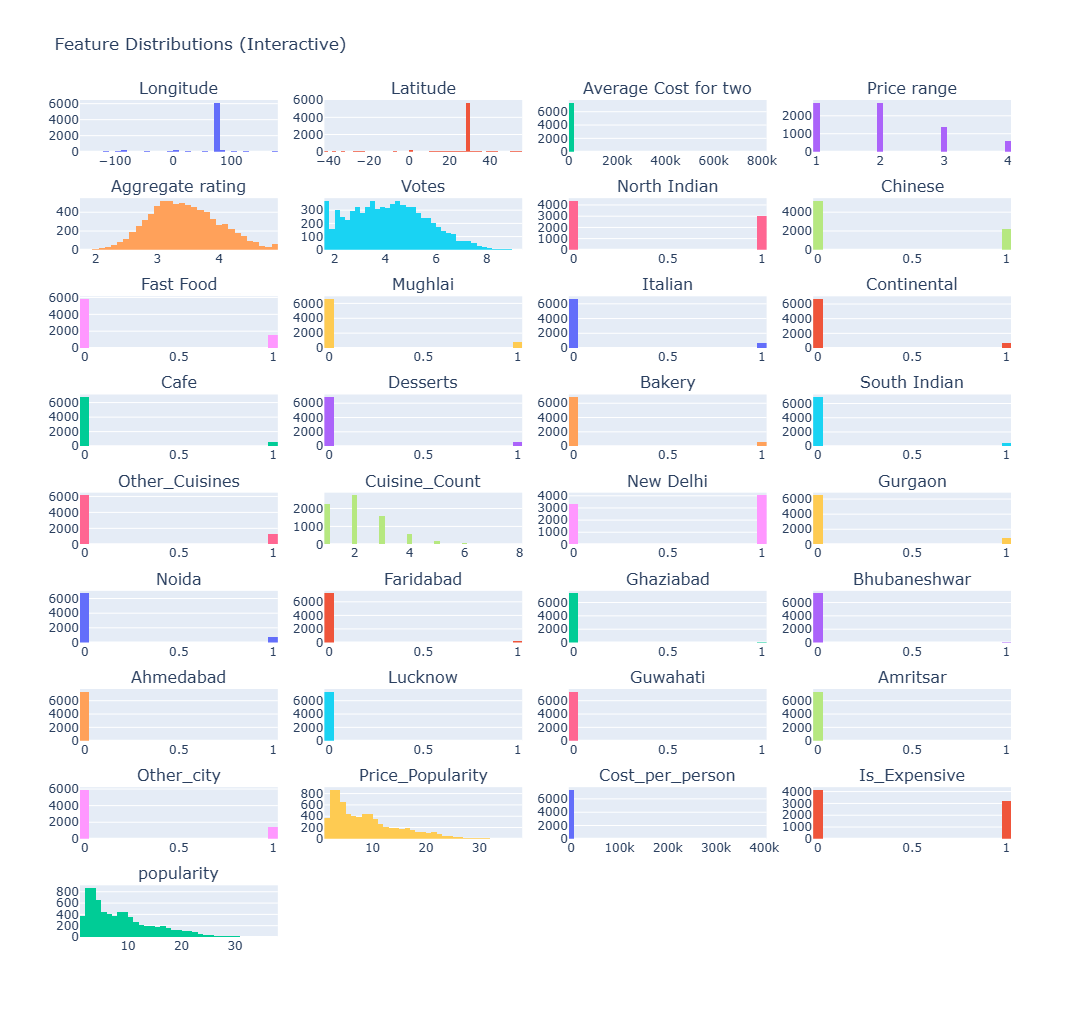

In [62]:
# Identify numerical columns
num_cols_to_plot = data.select_dtypes(include=[np.number]).columns

# Create a subplot grid
fig = make_subplots(rows=(len(num_cols_to_plot) // 4) + 1, cols=4, 
                    subplot_titles=num_cols_to_plot)

# Add histograms to the grid
for i, col in enumerate(num_cols_to_plot):
    fig.add_trace(
        go.Histogram(x=data[col], name=col, nbinsx=50),
        row=(i // 4) + 1, col=(i % 4) + 1
    )

fig.update_layout(height=1000, width=1200, title_text="Feature Distributions (Interactive)", showlegend=False)
fig.show()

## Creating Pipelines

In [54]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
import joblib
joblib.dump(pipeline, "Restaurant_rating_Predector.plk")

['Restaurant_rating_Predector.plk']

### Testing On Sample Data

In [56]:
sample = X_train.iloc[[0]].copy()
sample['City'] = 'Pune'
sample['Votes'] = 120
sample['Average Cost for two'] = 800
sample['Price range'] = 3
sample['Has Online delivery'] = 'Yes'
sample['Cuisines'] = 'North Indian'

prediction = pipeline.predict(sample)
print("Predicted Rating:", prediction[0])

Predicted Rating: 4.144000000000001
